Case study 4: Sphere
===

#### The first few cells in this notebook define the imports, physical and numerical parameters used in the case study. The parameters can be modified by the user to produce new results.


In this notebook we compute mean normal curvatures on the sphere. The sphere is computed from the analytical parameterisation of the sphere $f: \mathbb{R}^2 \rightarrow \mathbb{R}^3$:

$$
(x, y, z)=(R \cos \theta \sin \phi, R\sin \theta \sin \phi, R \cos \phi)
$$

where $R$ is the constant radius, $\theta \in[0,2 \pi)$ is the longitude and $\phi \in[0, \pi]$ is the colatitude. Pseudo-random points are generated in the domain $ [0,2 \pi)  \times [0, \pi]$ in a plane model of the sphere and then projected into 3D space using the mapping.

In [75]:
## Imports and physical parameters
# std library

# plotting

# ddg imports
# Allow for relative imports from main library:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from ddgclib._capillary_rise import * #plot_surface#, curvature
from ddgclib._plotting import *

# Parameters for a water droplet in air at standard laboratory conditions
gamma = 0.0728  # N/m, surface tension of water at 20 deg C
rho = 1000  # kg/m3, density
g = 9.81  # m/s2

# Parameters from EoS:
T_0 = 273.15 + 25  # K, initial tmeperature
P_0 = 101.325  # kPa, ambient pressure
#gamma = IAPWS(T_0)  # N/m, surface tension of water at 20 deg C
gamma = 0.0728  # N/m, surface tension of water at 20 deg C
#rho_0 = eos(P=P_0, T=T_0)  # kg/m3, densi
rho = 1000  # kg/m3, density
g = 9.81  # m/s2

# Capillary rise parameters
r = 0.15 # Radius of the tube (20 mm)
theta_p = 20 * np.pi/180.0  # Three phase contact angle
r = np.array(r, dtype=np.longdouble)
theta_p = np.array(theta_p, dtype=np.longdouble)


# Numerical parameters
N = 7  # Number of boundary points = N - 1
refinement = 0  # Number of refinements to the simplicial complex
cdist = 1e-10

In [131]:
def HC_curvatures_sessile(HC, bV, r, theta_p, printout=False):
    R = r / np.cos(theta_p)
    K_f = (1 / R) ** 2
    H_f = 2 / R  # 2 / R
    HNdA_ij = []
    HNdA_i = []
    HN_i = []
    C_ij = []
    K_H_i = []
    HNdA_i_Cij = []
    Theta_i = []

    N_i = []  # Temp cap rise normal

    HNdA_i_cache = {}
    HN_i_cache = {}
    C_ij_cache = {}
    K_H_i_cache = {}
    HNdA_i_Cij_cache = {}
    Theta_i_cache = {}

    for v in HC.V:
        #TODO: REMOVE UNDER NORMAL CONDITIONS:
        if 0:
            if v in bV:
                continue
        N_f0 = v.x_a - np.array([0.0, 0.0, 0.0])  # First approximation
        N_f0 = normalized(N_f0)[0]
        N_i.append(N_f0)
        F, nn = vectorise_vnn(v)
        # Compute discrete curvatures
        c_outd = b_curvatures_hn_ij_c_ij(F, nn, n_i=N_f0)
        # Append lists
        HNdA_ij.append(c_outd['HNdA_ij'])
        HNdA_i.append(c_outd['HNdA_i'])
        #HNdA_ij_dot.append(np.sum(np.dot(c_outd['HNdA_ij'], c_outd['n_i'])))
        HN_i.append(c_outd['HN_i'])
        C_ij.append(c_outd['C_ij'])
        K_H_i.append(c_outd['K_H_i'])
        HNdA_i_Cij.append(c_outd['HNdA_ij_Cij'])
        Theta_i.append(c_outd['theta_i'])
        
        # CIT paper:
        if 0:
            c_outd2 = b_curvatures_hn_ij_c_ij(F, nn, n_i=N_f0)
            HN_i_2.append(c_outd2['HN_i'])
            HNdA_i_list.append(c_outd2['HNdA_i'])
            C_ij_i_list.append(c_outd2['C_ij'])

        # Append chace
        HNdA_i_cache[v.x] = c_outd['HNdA_i']
        HN_i_cache[v.x] = c_outd['HN_i']
        C_ij_cache[v.x] = c_outd['C_ij']
        K_H_i_cache[v.x] = c_outd['K_H_i']
        HNdA_i_Cij_cache[v.x] = c_outd['HNdA_ij_Cij']
        Theta_i_cache[v.x] = c_outd['theta_i']

    if printout:
        print('.')
        print(f'HNdA_ij = {HNdA_ij}')
        print(f'HN_i = {HN_i}')
        print(f'C_ij = {C_ij}')
        print(f'K_H_i = {K_H_i}')
        print(f'HNdA_i_Cij = {HNdA_i_Cij}')
        print(f'Theta_i= {Theta_i}')
        print(f'np.array(Theta_i) in deg = {np.array(Theta_i) *180/np.pi}')
        print(f'np.array(Theta_i)/np.pi= {np.array(Theta_i) / np.pi}')
        rati = 2 * np.pi /np.array(Theta_i)
        rati = 2 * np.pi / (2 * np.pi - np.array(Theta_i))
        rati =  2 * np.pi / (2 * np.pi - np.array(Theta_i))
        rati =  (np.pi - np.array(Theta_i)/ 2 * np.pi )
        print(f' rati = { rati}')
        print(f'HNdA_i[1] * rati[1]  = {HNdA_ij[1] * rati[1] }')
        print(f'C_ij   = {C_ij }')
        print('.')
        print(f'HNdA_i_Cij = {HNdA_i_Cij}')

        print('-')
        print('Errors:')
        print('-')

        print(f'K_H_i - K_f = {np.array(K_H_i) - K_f}')
        print(f'HN_i  - H_f = {HN_i - H_f}')
        print(f'HNdA_i_Cij  - H_f = {HNdA_i_Cij - H_f}')

        #print(f'np.sum(C_ij) = {np.sum(C_ij)}')

    return (HNdA_i, HNdA_ij, HN_i, C_ij, K_H_i, HNdA_i_Cij, Theta_i,
            HNdA_i_cache, HN_i_cache, C_ij_cache, K_H_i_cache, HNdA_i_Cij_cache,
            Theta_i_cache)


In [132]:
import numpy as np
import matplotlib.pyplot as plt

def sphere(R, theta, phi):
    return R * np.cos(theta) * np.sin(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(phi)

def analytical_cap(r, theta_p):
    R = r / np.cos(theta_p)
    K_f = (1 / R) ** 2
    H_f = 2 / R  # 2 / R
    h = np.abs(R * np.sin(theta_p) - R)  # Height of the spherical cap
    # Area of spherical cap:
    dA = 2 * np.pi * R * h
    dC = 2 * np.pi * r
    a = R * np.cos(theta_p)
    # a = R * np.sin(theta_p)
    k_g_f = np.sqrt(R ** 2 - a ** 2) / (R * a)
    return H_f, K_f, dA, k_g_f, dC


In [183]:
def sphere_N(r, theta_p, R, refinement=2, cdist=1e-10, equilibrium=True):
   # Theta = np.linspace(0.0, 2 * np.pi, N)  # range of theta
   # v = Theta  # 0 to 2 pi
  #  u = 0.0    # [-2, 2.0
    #R = r / np.cos(theta_p)  # = R at theta = 0
    v_l, v_u = -1.5, 1.5
    def sphere(R, theta, phi):
        return R * np.cos(theta) * np.sin(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(phi)


    domain = [#(-2.0, 2.0),  # u
              (0.0, 2 * np.pi),  # u
              (0.0, np.pi)  # v
              ]
    
    domain = [#(-2.0, 2.0),  # u
          (0.00001, 1.9999 * np.pi),  # u
          (0.00001, 0.9999 *np.pi)  # v
          ]
        
    HC_plane = Complex(2, domain)
    HC_plane.triangulate()
    for i in range(refinement):
        HC_plane.refine_all()

    # H
    HC = Complex(3, domain)
    bV = set()
    cdist = 1e-8

    u_list = []
    v_list = []
    for v in HC_plane.V:
        x, y, z = sphere(R, v.x_a[0], v.x_a[1])
        v2 = HC.V[tuple([x, y, z])]
        u_list.append(v.x_a[0])
        v_list.append(v.x_a[1])

    # Connect neighbours
    if 1:
        for v in HC_plane.V:
            for vn in v.nn:
                v1 = list(HC.V)[v.index]
                v2 = list(HC.V)[vn.index]
                v1.connect(v2)

    # Remerge:
    HC.V.merge_all(cdist=cdist)

    return HC, bV

/home/endres/projects/ddg/ddgclib/ddgclib/_complex.py:2831: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  self.fig_complex.show()


(<Figure size 640x480 with 1 Axes>, <Axes3D:>, None, None)

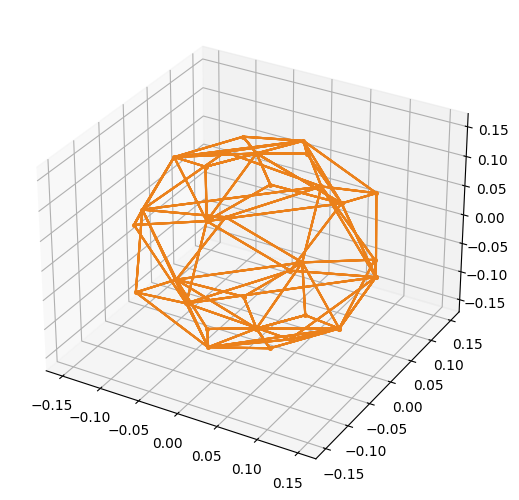

In [211]:
HC, bV = sphere_N(r, theta_p, r, refinement=2, cdist=1e-10, equilibrium=True)
HC.plot_complex()

In [212]:
(HNdA_i, HNdA_ij, HN_i, C_ij, K_H_i, HNdA_i_Cij, Theta_i,
            HNdA_i_cache, HN_i_cache, C_ij_cache, K_H_i_cache, HNdA_i_Cij_cache,
            Theta_i_cache) = HC_curvatures_sessile(HC, bV, r, theta_p, printout=0)
#np.sum(HNdA_ij, axis=0), 8*np.pi*r

In [213]:
HNdA_ij

[array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-3.12082451e-02,  9.80450275e-06,  1.29257631e-02],
        [ 7.23870275e-02,  7.23852843e-02, -2.03613086e-02],
        [-3.12082473e-02, -3.12082473e-07,  1.29257634e-02],
        [-4.13797334e-02,  4.13822593e-02,  0.00000000e+00],
        [ 7.23585569e-02, -7.24008446e-02, -2.03594936e-02],
        [-4.13856132e-02, -4.13763803e-02,  0.00000000e+00]],
       dtype=float128),
 array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-4.14015734e-02, -4.13789214e-02,  0.00000000e+00],
        [ 7.23182321e-02, -7.24418659e-02,  2.03872160e-02],
        [-3.11234969e-02,  9.77773525e-06, -1.29017541e-02]],
       dtype=float128),
 array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 7.23402626e-02,  7.24198663e-02,  2.03872160e-02],
        [-4.13889857e-02,  4.13915122e-02,  0.00000000e+00],
        [-3.11234985e-02, -3.11234985e-07, -1.29017541e-02]],
       dtype=float128),
 array([[ 

The tensors above are the components of the formula:

$$
\begin{aligned}
&\int_S H \boldsymbol{N} d A=\widehat{H N d} A=\frac{1}{2} \sum_{j \in s t\left(\boldsymbol{f}_i\right) \backslash \partial \mathcal{M}}\left(\cot \alpha_{i j}+\cot \beta_{i j}\right)\left(\boldsymbol{f}_i-\boldsymbol{f}_j\right) \\
&+\frac{1}{2} \sum_{k \in \operatorname{st}\left(\boldsymbol{f}_i\right) \cap \partial \mathcal{M}}\left(\cot \alpha_{i j}\right)\left(\boldsymbol{f}_i-\boldsymbol{f}_{\boldsymbol{k}}\right)
\end{aligned}
$$

Therefore the sum of each tensor is the sum of all local tensors:

$$\int_S H \boldsymbol{N}A_i=\widehat{H N d} A_i$$

At cell $k$ containing all the curvature vectors acting on a local surface area $A_k$, the surface tension force acting on the interface due to interface curvature is:

$$F_{s} = \gamma_{lg} \int_S H \boldsymbol{N}A_k = \gamma_{lg}\widehat{H N d} A_k$$

In [236]:
HNdA_i

[array([-2.18127230e-04, -9.44591533e-08, -7.43463781e-03], dtype=float128),
 array([-0.00010342, -0.0569055 ,  0.00374273], dtype=float128),
 array([-8.61107809e-05,  5.69055336e-02,  3.74273091e-03], dtype=float128),
 array([ 1.16853792e-01, -1.77710819e-05, -1.55733238e-05], dtype=float128),
 array([ 1.99815459e-04, -3.03878619e-08, -7.43554518e-03], dtype=float128),
 array([-5.84281373e-02,  1.24068121e-01, -7.78666188e-06], dtype=float128),
 array([-5.84658710e-02, -1.24050344e-01, -7.78666188e-06], dtype=float128),
 array([ 1.71083449e-04, -2.60183083e-08,  7.48546182e-03], dtype=float128),
 array([ 1.87013739e-05,  8.02222794e-02, -6.01185330e-02], dtype=float128),
 array([-5.69897615e-06, -8.02222814e-02, -6.01185330e-02], dtype=float128),
 array([1.87072634e-05, 8.02475432e-02, 6.01093172e-02], dtype=float128),
 array([-5.70077088e-06, -8.02475451e-02,  6.01093172e-02], dtype=float128),
 array([-8.07753151e-08,  1.99943102e-04, -7.43645261e-03], dtype=float128),
 array([ 8.022

Unfortunately, there is no way to directly compare this to any known analytical solutions (because the local areas are unknown), there we have to normalize to the approximate local areas $\widehat{A_k}$ and the compare to the analytical point-wise solution of $H = \frac{2}{r}$


$$\widehat{HN_k} = \frac{\int_S H \boldsymbol{N}A_k}{\widehat{A_k}}= \frac{\widehat{H N d} A_k }{\widehat{A_k}}$$

In [229]:
2/r, np.abs(np.array(HN_i)), (np.abs(np.array(HN_i))- 2/r)

(13.333333333333333827,
 array([ 2.97798197,  2.99995399,  2.99995399,  3.77630679,  2.97840801,
         3.77630679,  3.77630679,  2.99995399,  5.50780544,  5.50780544,
         5.50737359,  5.50737359,  2.9786903 ,  5.50780544,  5.50780546,
         3.77630679, 13.33333333, 13.33333333, 13.33309901, 13.33333333,
         2.97840801,  5.50780544,  3.77630679, 13.33333333, 13.33333333,
        13.33333333, 13.33333333,  5.50737359,  5.50737359,  2.99995399,
        13.33333333, 13.33333333, 13.33333333, 13.33333333,  5.50737359,
         2.99995399, 13.33333333, 13.33333333, 13.33333333, 13.33333333],
       dtype=float128),
 array([-1.03553514e+01, -1.03333793e+01, -1.03333793e+01, -9.55702655e+00,
        -1.03549253e+01, -9.55702655e+00, -9.55702655e+00, -1.03333793e+01,
        -7.82552789e+00, -7.82552789e+00, -7.82595974e+00, -7.82595974e+00,
        -1.03546430e+01, -7.82552789e+00, -7.82552787e+00, -9.55702655e+00,
         1.84140897e-15, -1.10415149e-15, -2.34325296e-04, -3.1

<IPython.core.display.Javascript object>


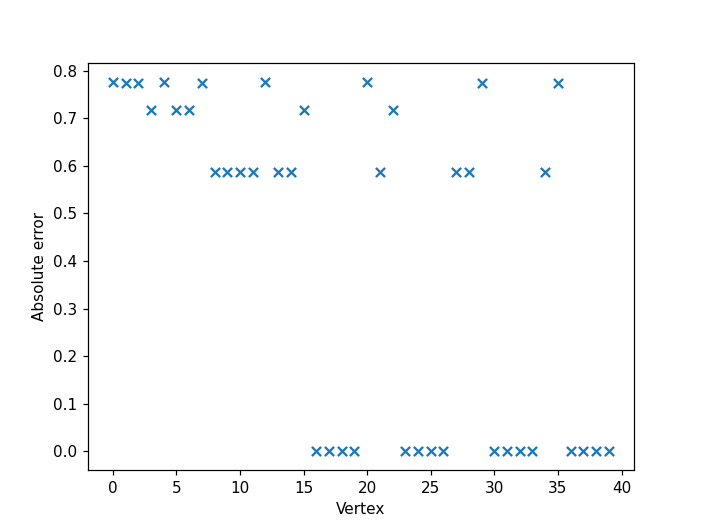

In [237]:
%matplotlib notebook
plt.scatter(list(range(len((np.abs(np.array(HN_i)))))), (abs((np.abs(np.array(HN_i))- 2/r)))/(2/r), marker='x')
plt.ylabel('Absolute error')
plt.xlabel('Vertex')
plt.show()

In [217]:
sum_HNdA_i

array([-4.74338450e-20, -6.09863722e-20, -2.37169225e-20], dtype=float128)

In [218]:
np.sum(HNdA_i, axis=0)
#np.dot(hndA_i_c_ij, [0, 0, -1])

array([-4.74338450e-20, -6.09863722e-20, -2.37169225e-20], dtype=float128)

We _always_ expect the total integrated solution to . From the point-wise mean ("fluid mean") curvature of $H = \frac{2}{r}$ and an area of $A = 4\pi r^2$ we get the analytical solution of the sphere as 

$$ \int H N dA = \frac{2}{r} \cdot 4\pi r^2 = 8 \pi r  $$

and compared to our total solution:

$$\int_S H \boldsymbol{N}A=\widehat{H N d} A$$

In [220]:
np.sum(np.linalg.norm(HNdA_i, axis=1)), 8*np.pi*r

(3.7699111843077515998, 3.7699111843077515998)

In [231]:
np.sum(np.linalg.norm(HNdA_i, axis=1)) - 8*np.pi*r

0.0